# Attendance Management Dashboard — Source Code
### Round 3 Submission

This notebook contains the complete, working source code for the Attendance
Management Dashboard project, implementing the algorithm and process flow
defined in **Round 1** and the dataset schema defined in **Round 2**.

**Process Flow implemented below:**

`Attendance Data Collection → Data Import → Data Cleaning → Data Transformation → Attendance Calculation → KPI Generation → Data Aggregation → Visualization → Interactive Dashboard → Attendance Insights`


## 0. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 6)


## Step 1 & 2: Attendance Data Collection & Data Import

A demonstration attendance dataset is generated here in the exact schema
defined in the Round 2 dataset document (`Student_ID`, `Student_Name`,
`Class_Section`, `Subject`, `Attendance_Date`, `Attendance_Status`,
`Faculty`), saved as a CSV file, and then imported back — simulating the
real "collect → import from Excel/CSV" step of the pipeline.

Some missing values, inconsistent text casing, and duplicate rows are
deliberately injected so that the cleaning step below has real, verifiable
work to do.

In [2]:
def generate_demo_dataset(n_students=40, n_days=30, out_path="attendance_raw.csv"):
    students = [f"S{i:03d}" for i in range(1, n_students + 1)]
    names = [f"Student_{i}" for i in range(1, n_students + 1)]
    sections = ["A", "B", "C"]
    subjects = ["Maths", "Physics", "Chemistry", "English", "Computer Science"]
    faculty_map = {
        "Maths": "Mr. Rao",
        "Physics": "Mrs. Iyer",
        "Chemistry": "Mr. Khan",
        "English": "Ms. Fernandes",
        "Computer Science": "Mr. Sharma",
    }

    student_section = {sid: random.choice(sections) for sid in students}

    start_date = datetime(2026, 1, 1)
    rows = []
    for day in range(n_days):
        date = start_date + timedelta(days=day)
        if date.weekday() >= 5:          # skip weekends
            continue
        for sid, name in zip(students, names):
            for subject in subjects:
                status = np.random.choice(["Present", "Absent"], p=[0.85, 0.15])
                rows.append({
                    "Student_ID": sid,
                    "Student_Name": name,
                    "Class_Section": student_section[sid],
                    "Subject": subject,
                    "Attendance_Date": date.strftime("%Y-%m-%d"),
                    "Attendance_Status": status,
                    "Faculty": faculty_map[subject],
                })

    df = pd.DataFrame(rows)

    # Inject messy data: missing values, inconsistent casing, duplicates
    dirty_idx = df.sample(frac=0.02, random_state=1).index
    df.loc[dirty_idx[:len(dirty_idx)//3], "Attendance_Status"] = None
    df.loc[dirty_idx[len(dirty_idx)//3: 2*len(dirty_idx)//3], "Attendance_Status"] = "present "
    df = pd.concat([df, df.sample(5, random_state=2)], ignore_index=True)

    df.to_csv(out_path, index=False)
    return out_path


def import_attendance_data(path):
    """Import the attendance data from a structured CSV file."""
    return pd.read_csv(path)


raw_path = generate_demo_dataset()
df_raw = import_attendance_data(raw_path)
df_raw.head()


,Student_ID,Student_Name,Class_Section,Subject,Attendance_Date,Attendance_Status,Faculty
0,S001,Student_1,C,Maths,2026-01-01,Present,Mr. Rao
1,S001,Student_1,C,Physics,2026-01-01,Absent,Mrs. Iyer
2,S001,Student_1,C,Chemistry,2026-01-01,Present,Mr. Khan
3,S001,Student_1,C,English,2026-01-01,Present,Ms. Fernandes
4,S001,Student_1,C,Computer Science,2026-01-01,Present,Mr. Sharma


## Step 3: Inspect the Dataset

Identify missing values, duplicate records, and inconsistent status
values before cleaning.

In [3]:
def inspect_dataset(df):
    return {
        "total_records": len(df),
        "missing_values": df.isnull().sum().to_dict(),
        "duplicate_records": int(df.duplicated().sum()),
        "unique_status_values": df["Attendance_Status"].dropna().unique().tolist(),
    }

inspection_report = inspect_dataset(df_raw)
inspection_report


{'total_records': 4405, 'missing_values': {'Student_ID': 0, 'Student_Name': 0, 'Class_Section': 0, 'Subject': 0, 'Attendance_Date': 0, 'Attendance_Status': 29, 'Faculty': 0}, 'duplicate_records': 5, 'unique_status_values': ['Present', 'Absent', 'present ']}

## Step 4 & 5: Data Cleaning and Standardization

- Remove exact duplicate rows
- Fix inconsistent `Attendance_Status` values (whitespace, casing)
- Drop rows with invalid/missing status (core field for all calculations)
- Standardize `Student_ID`, `Student_Name`, `Class_Section`, `Subject`
- Convert `Attendance_Date` to a proper date type

In [4]:
def clean_and_standardize(df):
    df = df.copy()
    df = df.drop_duplicates()

    df["Attendance_Status"] = df["Attendance_Status"].astype(str).str.strip().str.capitalize()
    df.loc[~df["Attendance_Status"].isin(["Present", "Absent"]), "Attendance_Status"] = np.nan
    df = df.dropna(subset=["Attendance_Status"])

    df["Student_ID"] = df["Student_ID"].astype(str).str.strip().str.upper()
    df["Student_Name"] = df["Student_Name"].astype(str).str.strip()
    df["Class_Section"] = df["Class_Section"].astype(str).str.strip().str.upper()
    df["Subject"] = df["Subject"].astype(str).str.strip()

    df["Attendance_Date"] = pd.to_datetime(df["Attendance_Date"], errors="coerce")
    df = df.dropna(subset=["Attendance_Date"])

    return df.reset_index(drop=True)

df_clean = clean_and_standardize(df_raw)
print("Rows before cleaning:", len(df_raw), "| Rows after cleaning:", len(df_clean))
df_clean.head()


Rows before cleaning: 4405 | Rows after cleaning: 4371


,Student_ID,Student_Name,Class_Section,Subject,Attendance_Date,Attendance_Status,Faculty
0,S001,Student_1,C,Maths,2026-01-01,Present,Mr. Rao
1,S001,Student_1,C,Physics,2026-01-01,Absent,Mrs. Iyer
2,S001,Student_1,C,Chemistry,2026-01-01,Present,Mr. Khan
3,S001,Student_1,C,English,2026-01-01,Present,Ms. Fernandes
4,S001,Student_1,C,Computer Science,2026-01-01,Present,Mr. Sharma


## Step 6: Data Transformation (analysis-ready structure)

In [5]:
def transform_data(df):
    df = df.copy()
    df["Is_Present"] = (df["Attendance_Status"] == "Present").astype(int)
    df["Month"] = df["Attendance_Date"].dt.to_period("M").astype(str)
    return df

df_final = transform_data(df_clean)
df_final.head()


,Student_ID,Student_Name,Class_Section,Subject,Attendance_Date,Attendance_Status,Faculty,Is_Present,Month
0,S001,Student_1,C,Maths,2026-01-01,Present,Mr. Rao,1,2026-01
1,S001,Student_1,C,Physics,2026-01-01,Absent,Mrs. Iyer,0,2026-01
2,S001,Student_1,C,Chemistry,2026-01-01,Present,Mr. Khan,1,2026-01
3,S001,Student_1,C,English,2026-01-01,Present,Ms. Fernandes,1,2026-01
4,S001,Student_1,C,Computer Science,2026-01-01,Present,Mr. Sharma,1,2026-01


## Step 7: Attendance Calculation

`Attendance Percentage = (Number of Classes Attended / Total Number of Classes) × 100`

In [6]:
def calculate_attendance(df, group_cols):
    summary = (
        df.groupby(group_cols)
        .agg(Present_Count=("Is_Present", "sum"), Total_Classes=("Is_Present", "count"))
        .reset_index()
    )
    summary["Absent_Count"] = summary["Total_Classes"] - summary["Present_Count"]
    summary["Attendance_Percentage"] = (
        summary["Present_Count"] / summary["Total_Classes"] * 100
    ).round(2)
    return summary

student_summary = calculate_attendance(df_final, ["Student_ID", "Student_Name"])
student_summary.head()


,Student_ID,Student_Name,Present_Count,Total_Classes,Absent_Count,Attendance_Percentage
0,S001,Student_1,95,110,15,86.36
1,S002,Student_2,92,110,18,83.64
2,S003,Student_3,97,108,11,89.81
3,S004,Student_4,97,109,12,88.99
4,S005,Student_5,96,110,14,87.27


## Step 8: KPI Generation

Total students, average attendance, present/absent counts, and
low-attendance student count (threshold-based).

In [7]:
def generate_kpis(df, student_summary, low_attendance_threshold=75.0):
    return {
        "Total_Students": df["Student_ID"].nunique(),
        "Total_Classes_Recorded": len(df),
        "Average_Attendance_Percentage": round(student_summary["Attendance_Percentage"].mean(), 2),
        "Total_Present_Count": int(df["Is_Present"].sum()),
        "Total_Absent_Count": int((1 - df["Is_Present"]).sum()),
        "Low_Attendance_Student_Count": int(
            (student_summary["Attendance_Percentage"] < low_attendance_threshold).sum()
        ),
    }

kpis = generate_kpis(df_final, student_summary)
kpis


{'Total_Students': 40, 'Total_Classes_Recorded': 4371, 'Average_Attendance_Percentage': np.float64(85.61), 'Total_Present_Count': 3742, 'Total_Absent_Count': 629, 'Low_Attendance_Student_Count': 0}

## Step 9: Summarization — by Student, Subject, Class/Section, and Time Period

In [8]:
def build_summaries(df):
    return {
        "by_student": calculate_attendance(df, ["Student_ID", "Student_Name"]),
        "by_subject": calculate_attendance(df, ["Subject"]),
        "by_section": calculate_attendance(df, ["Class_Section"]),
        "by_month": calculate_attendance(df, ["Month"]),
    }

summaries = build_summaries(df_final)
summaries["by_subject"]


,Subject,Present_Count,Total_Classes,Absent_Count,Attendance_Percentage
0,Chemistry,759,874,115,86.84
1,Computer Science,748,872,124,85.78
2,English,753,877,124,85.86
3,Maths,748,874,126,85.58
4,Physics,734,874,140,83.98


## Step 10: Charts, Tables, and KPI Cards (Dashboard Visualization)

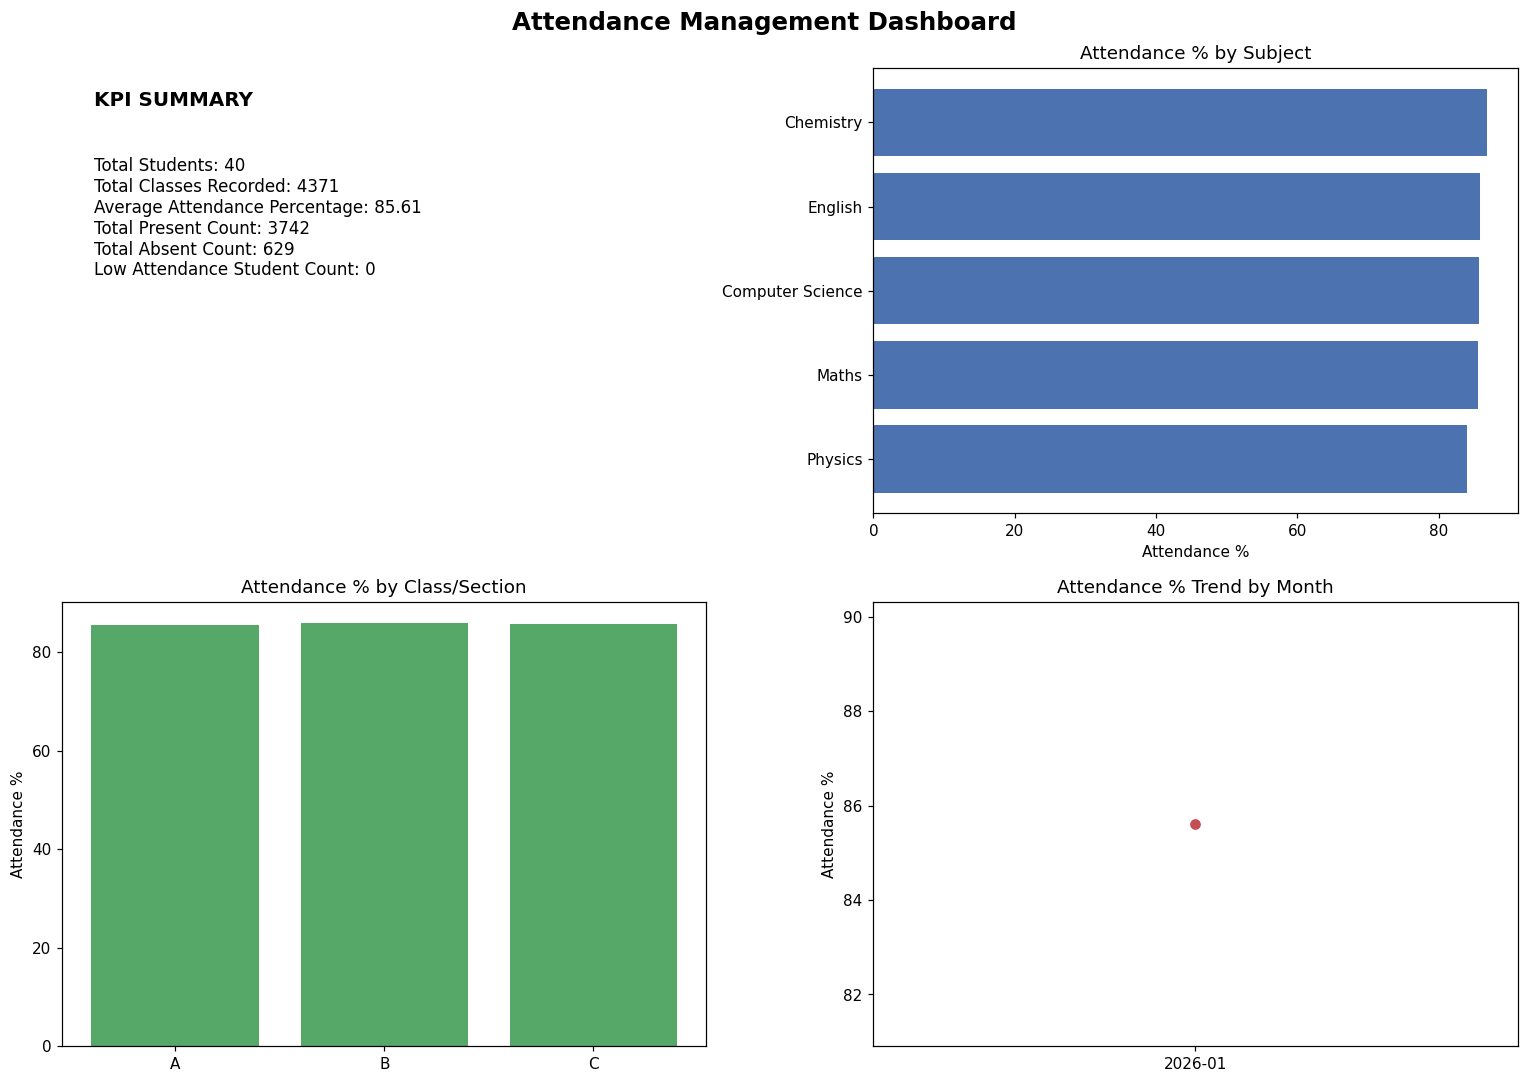

In [9]:
def render_dashboard(summaries, kpis, save_path="dashboard.png"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Attendance Management Dashboard", fontsize=16, fontweight="bold")

    ax = axes[0, 0]
    ax.axis("off")
    kpi_text = "\n".join([f"{k.replace('_', ' ')}: {v}" for k, v in kpis.items()])
    ax.text(0.05, 0.95, "KPI SUMMARY", fontsize=13, fontweight="bold", va="top")
    ax.text(0.05, 0.80, kpi_text, fontsize=11, va="top")

    ax = axes[0, 1]
    data = summaries["by_subject"].sort_values("Attendance_Percentage")
    ax.barh(data["Subject"], data["Attendance_Percentage"], color="#4C72B0")
    ax.set_title("Attendance % by Subject")
    ax.set_xlabel("Attendance %")

    ax = axes[1, 0]
    data = summaries["by_section"].sort_values("Class_Section")
    ax.bar(data["Class_Section"], data["Attendance_Percentage"], color="#55A868")
    ax.set_title("Attendance % by Class/Section")
    ax.set_ylabel("Attendance %")

    ax = axes[1, 1]
    data = summaries["by_month"].sort_values("Month")
    ax.plot(data["Month"], data["Attendance_Percentage"], marker="o", color="#C44E52")
    ax.set_title("Attendance % Trend by Month")
    ax.set_ylabel("Attendance %")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

render_dashboard(summaries, kpis)


## Step 11: Interactive Filters

Filter functions for student, subject, class/section, and time period —
mirroring the interactive filter controls a BI tool (e.g. Power BI) would
expose on the dashboard.

In [10]:
def filter_attendance(df, student_id=None, subject=None, class_section=None,
                       start_date=None, end_date=None):
    result = df.copy()
    if student_id:
        result = result[result["Student_ID"] == student_id]
    if subject:
        result = result[result["Subject"] == subject]
    if class_section:
        result = result[result["Class_Section"] == class_section]
    if start_date:
        result = result[result["Attendance_Date"] >= pd.to_datetime(start_date)]
    if end_date:
        result = result[result["Attendance_Date"] <= pd.to_datetime(end_date)]
    return result

# Example: filter to a single subject and class/section
filter_attendance(df_final, subject="Maths", class_section="A").head()


,Student_ID,Student_Name,Class_Section,Subject,Attendance_Date,Attendance_Status,Faculty,Is_Present,Month
5,S002,Student_2,A,Maths,2026-01-01,Present,Mr. Rao,1,2026-01
10,S003,Student_3,A,Maths,2026-01-01,Present,Mr. Rao,1,2026-01
25,S006,Student_6,A,Maths,2026-01-01,Present,Mr. Rao,1,2026-01
30,S007,Student_7,A,Maths,2026-01-01,Present,Mr. Rao,1,2026-01
35,S008,Student_8,A,Maths,2026-01-01,Present,Mr. Rao,1,2026-01


## Step 12 & 13: Present the Dashboard & Validate Calculations

Cross-check KPI totals against the cleaned dataset to confirm the
dashboard's numbers are internally consistent.

In [11]:
def validate_dashboard(df, student_summary):
    checks = {}
    checks["present_count_matches"] = bool(df["Is_Present"].sum() == student_summary["Present_Count"].sum())
    checks["total_classes_match"] = bool(len(df) == student_summary["Total_Classes"].sum())
    checks["percentage_range_valid"] = bool(student_summary["Attendance_Percentage"].between(0, 100).all())
    return checks

validation = validate_dashboard(df_final, summaries["by_student"])
validation


{'present_count_matches': True, 'total_classes_match': True, 'percentage_range_valid': True}

## Attendance Insights (Students Needing Attention)

Students whose attendance percentage falls below the defined threshold.

In [12]:
low_attendance_students = summaries["by_student"][
    summaries["by_student"]["Attendance_Percentage"] < 75.0
].sort_values("Attendance_Percentage")

low_attendance_students


,Student_ID,Student_Name,Present_Count,Total_Classes,Absent_Count,Attendance_Percentage


## Summary

This notebook implements the full pipeline described in Round 1 (Algorithm)
and Round 2 (Dataset): data collection, import, cleaning, standardization,
transformation, attendance-percentage calculation, KPI generation,
multi-level summarization, dashboard visualization, interactive filtering,
and validation — completing the descriptive-analytics Attendance
Management Dashboard end to end.